# Week 5 - Function 8 ((44DP, 8D))

# Setup

In [28]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats.qmc import LatinHypercube
from ipywidgets import interact, FloatSlider

from utils.plotting_utils import (
    plot_8D_shap_analysis,
    plot_output_outliers,
    plot_nd_mean_uncertainty_slice
)

# Plan
We now have ((44, 8)) — 44 data points, 8 dimensions, from `./data/week_5/function_8/`.

**Architecture**: Single GP (ARD Matern 2.5) with StandardScaler output, noise-dim dropping, and UCB acquisition.

**Key decisions** (carried forward):
- StandardScaler: well-behaved outputs (y ∈ [5.59, 9.60])
- Full 8D GP → ARD identifies x6, x8 as noise (ls > 1e4) → refit on 6 active dims
- UCB kappa=4.31 (budget-aware: week 4/13)
- 100K LHS candidates in 6D active space; noise dims set to training mean

**Changes this week:**
- kappa updated from 5.0 → 4.31 (budget-aware)
- Noise dim values changed from hardcoded 0.5 → training-data mean

**Steps:** Load data → Preprocessing → Full 8D GP (ARD) → Feature selection → Interactive visualization → Acquisition → Report


# 1. Load data

In [29]:
X_train_raw = np.load(r"./data/week_5/function_8/inputs.npy")
y_train_raw = np.load(r"./data/week_5/function_8/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(44, 8), y=(44,)
X range: [0.0034, 0.9989]
y range: [5.59e+00, 9.85e+00]


/opt/anaconda3/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


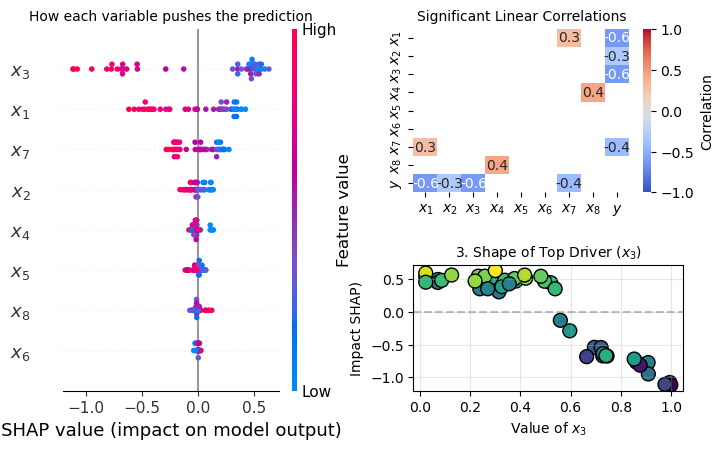

In [30]:
plot_8D_shap_analysis(X_train_raw, y_train_raw)

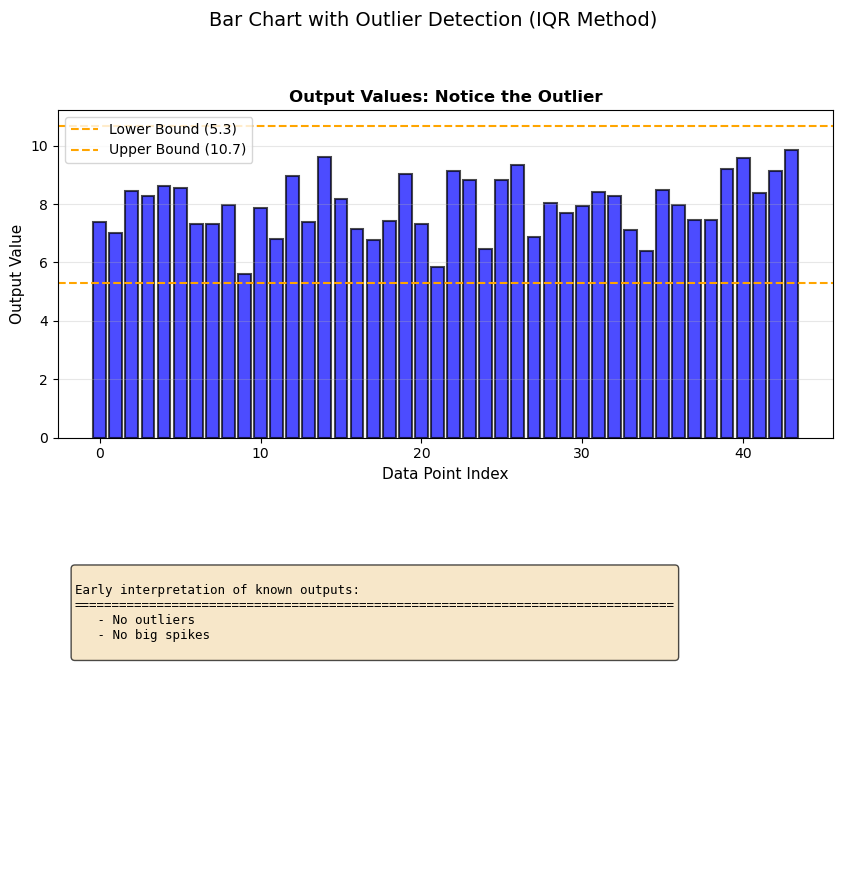

In [31]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*80}
   - No outliers
   - No big spikes
""")

# 2. Preprocessing

No outliers, so StandardScaler is appropriate.

In [32]:
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print(f"Total points: {len(X_train)}")
print(f"Scaled y range: [{y_train.min():.2f}, {y_train.max():.2f}]")

Total points: 44
Scaled y range: [-2.34, 1.90]


# 3. GP with ARD (full 8D) — identify noise dimensions

We first fit on all 8 dims. Dimensions with very large length scales (> 1e6) are noise and can be dropped.

In [33]:
kernel_full = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5]*8, nu=2.5,
    length_scale_bounds=(1e-3, 1e12)
)

model_full = GaussianProcessRegressor(
    kernel=kernel_full,
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=30
)

model_full.fit(X_train, y_train)
print(f"Full 8D Kernel: {model_full.kernel_}")

learned_scales = model_full.kernel_.k2.length_scale
importance = 1.0 / learned_scales
importance_norm = importance / importance.sum() * 100

print(f"\nFeature Importance (from ARD length scales):")
print(f"{'Dim':<6} {'Length Scale':<20} {'Importance %':<15} {'Role'}")
print("=" * 80)
noise_threshold = 1e4
noise_dims = []
active_dims = []
sorted_dims = np.argsort(learned_scales)
for i in sorted_dims:
    if learned_scales[i] > noise_threshold:
        role = 'NOISE (drop)'
        noise_dims.append(i)
    elif learned_scales[i] > 10.0:
        role = 'weak'
        active_dims.append(i)
    else:
        role = 'IMPORTANT'
        active_dims.append(i)
    print(f"x{i+1:<5} {learned_scales[i]:<20.4f} {importance_norm[i]:<15.4f} {role}")

print(f"\nNoise dims (length scale > {noise_threshold:.0e}): {['x'+str(d+1) for d in noise_dims]}")
print(f"Active dims: {['x'+str(d+1) for d in active_dims]}")

Full 8D Kernel: 4.47**2 * Matern(length_scale=[3.2, 4.45, 2.36, 12.2, 15.6, 7.02e+05, 3.42, 4.17e+05], nu=2.5)

Feature Importance (from ARD length scales):
Dim    Length Scale         Importance %    Role
x3     2.3557               30.3211         IMPORTANT
x1     3.1964               22.3460         IMPORTANT
x7     3.4243               20.8590         IMPORTANT
x2     4.4530               16.0403         IMPORTANT
x4     12.1763              5.8661          weak
x5     15.6389              4.5672          weak
x8     416684.4546          0.0002          NOISE (drop)
x6     701649.4846          0.0001          NOISE (drop)

Noise dims (length scale > 1e+04): ['x8', 'x6']
Active dims: ['x3', 'x1', 'x7', 'x2', 'x4', 'x5']


# 4. Feature selection — refit GP on active dims only

Drop noise dimensions and refit. This reduces the effective dimensionality and improves GP predictions.

In [34]:
n_active = len(active_dims)
X_train_active = X_train[:, active_dims]
print(f"Effective dimensionality: {n_active}D (dropped {len(noise_dims)} noise dims)")

kernel_active = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5]*n_active, nu=2.5,
    length_scale_bounds=(1e-3, 1e2)
)

model = GaussianProcessRegressor(
    kernel=kernel_active,
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=30
)

model.fit(X_train_active, y_train)
print(f"Active-dim kernel: {model.kernel_}")

# Feature importance within active dims
ls_active = model.kernel_.k2.length_scale
imp_active = 1.0 / ls_active
imp_active_norm = imp_active / imp_active.sum() * 100

print(f"\nActive dim importance:")
sorted_active = np.argsort(ls_active)
for j in sorted_active:
    orig_dim = active_dims[j]
    print(f"  x{orig_dim+1}: ls={ls_active[j]:.4f}, importance={imp_active_norm[j]:.1f}%")

# Determine plot/slider dims (within active space)
most_important_active = sorted_active[:2]
slider_active = sorted_active[2:]
dim_a_orig = active_dims[most_important_active[0]]
dim_b_orig = active_dims[most_important_active[1]]
slider_dims_orig = [active_dims[j] for j in slider_active]
print(f"\nPlotting dims: x{dim_a_orig+1}, x{dim_b_orig+1}")
print(f"Slider dims: {['x'+str(d+1) for d in slider_dims_orig]}")

Effective dimensionality: 6D (dropped 2 noise dims)
Active-dim kernel: 4.47**2 * Matern(length_scale=[2.36, 3.2, 3.42, 4.45, 12.2, 15.6], nu=2.5)

Active dim importance:
  x3: ls=2.3557, importance=30.3%
  x1: ls=3.1964, importance=22.3%
  x7: ls=3.4244, importance=20.9%
  x2: ls=4.4529, importance=16.0%
  x4: ls=12.1752, importance=5.9%
  x5: ls=15.6397, importance=4.6%

Plotting dims: x3, x1
Slider dims: ['x7', 'x2', 'x4', 'x5']


# 5. Interactive GP Visualization

In [35]:
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

def plot_gp_slice(**kwargs):
    # Build grid in active-dim space
    grid_active = np.zeros((n_grid_2d * n_grid_2d, n_active))
    grid_active[:, most_important_active[0]] = X1_plot.ravel()
    grid_active[:, most_important_active[1]] = X2_plot.ravel()
    for j in slider_active:
        orig_dim = active_dims[j]
        grid_active[:, j] = kwargs[f'x{orig_dim+1}']
    
    mu, sigma = model.predict(grid_active, return_std=True)
    
    fixed_parts = [f'x{active_dims[j]+1}={kwargs[f"x{active_dims[j]+1}"]:.2f}' for j in slider_active]
    noise_parts = [f'x{d+1}=dropped' for d in noise_dims]
    fixed_info = ', '.join(fixed_parts + noise_parts)
    
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu.reshape(n_grid_2d, n_grid_2d),
        sigma.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a_orig, dim2_idx=dim_b_orig,
        title_prefix='GP Mean & Uncertainty',
        fixed_info=fixed_info
    )

slider_kwargs = {
    f'x{active_dims[j]+1}': FloatSlider(min=0, max=1, step=0.05, value=0.5, description=f'x{active_dims[j]+1}')
    for j in slider_active
}
interact(plot_gp_slice, **slider_kwargs)

interactive(children=(FloatSlider(value=0.5, description='x7', max=1.0, step=0.05), FloatSlider(value=0.5, des…

<function __main__.plot_gp_slice(**kwargs)>

# 6. Acquisition Function (UCB on LHS candidates)

100,000 LHS candidates in the effective active-dim space. Noise dims are fixed at 0.5.

In [36]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

# Generate LHS candidates in active-dim space
sampler = LatinHypercube(d=n_active, seed=42)
X_cand_active = sampler.random(n=100_000)

# GP predictions on candidates
mu_cand, sigma_cand = model.predict(X_cand_active, return_std=True)

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 5
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

ucb_values = upper_confidence_bound(mu_cand, sigma_cand, kappa=kappa)

best_idx = np.argmax(ucb_values)
x_best_active = X_cand_active[best_idx]

# Reconstruct full 8D point: active dims from best candidate, noise dims at training mean
x_next_norm_full = np.zeros(8)
for j, orig_dim in enumerate(active_dims):
    x_next_norm_full[orig_dim] = x_best_active[j]
for d in noise_dims:
    x_next_norm_full[d] = X_train[:, d].mean()

x_next_orig = scaler_X.inverse_transform([x_next_norm_full])[0]

print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (UCB, kappa={kappa:.2f}, 100K LHS in {n_active}D active space)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")

y_pred, y_std = model.predict([x_best_active], return_std=True)
print(f"  GP prediction: {y_pred[0]:.4f} +/- {y_std[0]:.4f}")
print(f"  UCB value: {ucb_values[best_idx]:.4f}")

print(f"\nSanity check - is this a corner?")
for i in range(8):
    if i in noise_dims:
        print(f"  x{i+1} = {x_next_norm_full[i]:.4f} (noise, fixed at training mean)")
    else:
        at_boundary = x_next_norm_full[i] < 0.02 or x_next_norm_full[i] > 0.98
        print(f"  x{i+1} = {x_next_norm_full[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max():.6f})")


kappa = 4.0769 (week 5/13)
RECOMMENDED NEXT POINT (UCB, kappa=4.08, 100K LHS in 6D active space)
  Input (original space): [0.260503 0.115282 0.227557 0.061515 0.939305 0.440824 0.26289  0.507323]
  GP prediction: 1.9499 +/- 0.0930
  UCB value: 2.3290

Sanity check - is this a corner?
  x1 = 0.2574 
  x2 = 0.1153 
  x3 = 0.2097 
  x4 = 0.0587 
  x5 = 0.9513 
  x6 = 0.4325 (noise, fixed at training mean)
  x7 = 0.2372 
  x8 = 0.4915 (noise, fixed at training mean)

Current best: [0.024682 0.033114 0.300126 0.038225 0.86567  0.440824 0.106641 0.507323] (y = 9.851721)
